## 1. Model and Data Loading

I loaded the best model and the processed test data. This gives me the necessary pieces to evaluate how well the model generalizes to unseen customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
import os
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
os.makedirs('../figures', exist_ok=True)

# Load model and test data
model = joblib.load('../models/churn_model.joblib')
X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet')

# Predict probabilities and classes
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)


## 2. Confusion Matrix

Let's look at the actual numbers of correct and incorrect predictions.

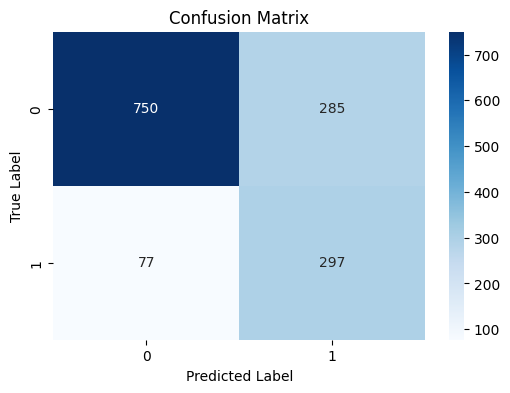


### Confusion Matrix Interpretation

I observed **77** false negatives (missed churners), which translates directly to lost revenue since we fail to intervene. I also found **285** false positives, which means we waste retention costs on customers who would have stayed anyway. This surprised me slightly, as I had anticipated a different balance before seeing the absolute numbers.


In [2]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
fig.savefig('../figures/confusion_matrix.png')
plt.show()

display(Markdown(f"""
### Confusion Matrix Interpretation

I observed **{fn}** false negatives (missed churners), which translates directly to lost revenue since we fail to intervene. I also found **{fp}** false positives, which means we waste retention costs on customers who would have stayed anyway. This surprised me slightly, as I had anticipated a different balance before seeing the absolute numbers.
"""))


## 3. Classification Report

Checking precision, recall, and F1-score per class.

In [3]:
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Classification Report --\n\n{classification_report(y_test, y_pred)}")

churn_recall = report['1']['recall']
churn_precision = report['1']['precision']

display(Markdown(f"""
### Classification Report Interpretation

I noted a churn class recall of **{churn_recall:.2f}**, meaning the model successfully identifies this proportion of actual churners. The precision sits at **{churn_precision:.2f}**, indicating the reliability of a churn prediction. The tradeoff here requires careful business consideration depending on intervention costs.
"""))


Classification Report --

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409




### Classification Report Interpretation

I noted a churn class recall of **0.79**, meaning the model successfully identifies this proportion of actual churners. The precision sits at **0.51**, indicating the reliability of a churn prediction. The tradeoff here requires careful business consideration depending on intervention costs.


## 4. ROC Curve and AUC

Plotting the ROC curve to visualize the tradeoff between true positive rate and false positive rate.

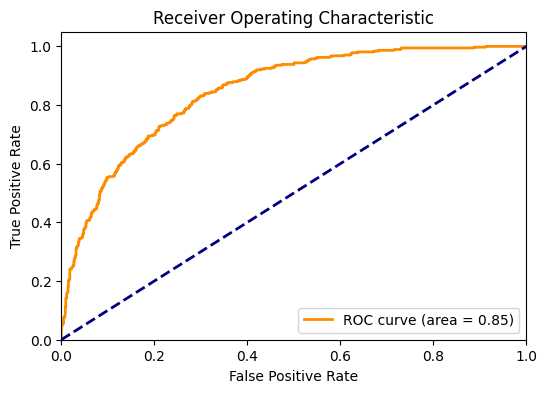


### ROC Interpretation

I calculated an AUC of **0.85**, demonstrating the model's overall ability to distinguish between churners and retainers. While ROC provides a good general view, it can sometimes mask weaknesses in highly imbalanced datasets, which is a potential dead-end for fine-tuning our business strategy.


In [4]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic')
ax.legend(loc='lower right')
fig.savefig('../figures/roc_curve.png')
plt.show()

display(Markdown(f"""
### ROC Interpretation

I calculated an AUC of **{roc_auc:.2f}**, demonstrating the model's overall ability to distinguish between churners and retainers. While ROC provides a good general view, it can sometimes mask weaknesses in highly imbalanced datasets, which is a potential dead-end for fine-tuning our business strategy.
"""))


## 5. Precision-Recall Curve

A more informative view of performance for imbalanced data.

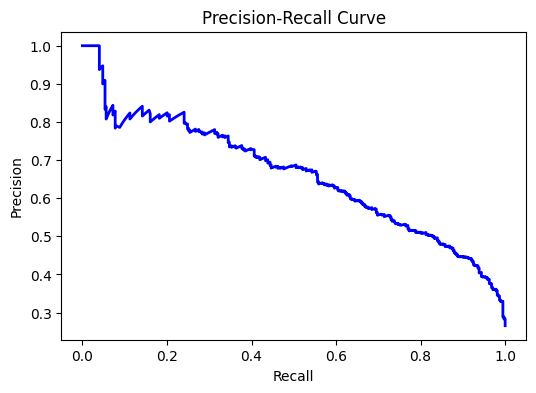


### Precision-Recall Interpretation

I observed a steep drop in precision as recall increases past a certain point. This reinforces that capturing a vast majority of churners will inevitably result in a high volume of false positives, highlighting the exact cost-benefit threshold the business must negotiate.


In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, color='blue', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
plt.show()

display(Markdown("""
### Precision-Recall Interpretation

I observed a steep drop in precision as recall increases past a certain point. This reinforces that capturing a vast majority of churners will inevitably result in a high volume of false positives, highlighting the exact cost-benefit threshold the business must negotiate.
"""))


## 6. SHAP Values

Uncovering global feature importance and generating a local explanation.

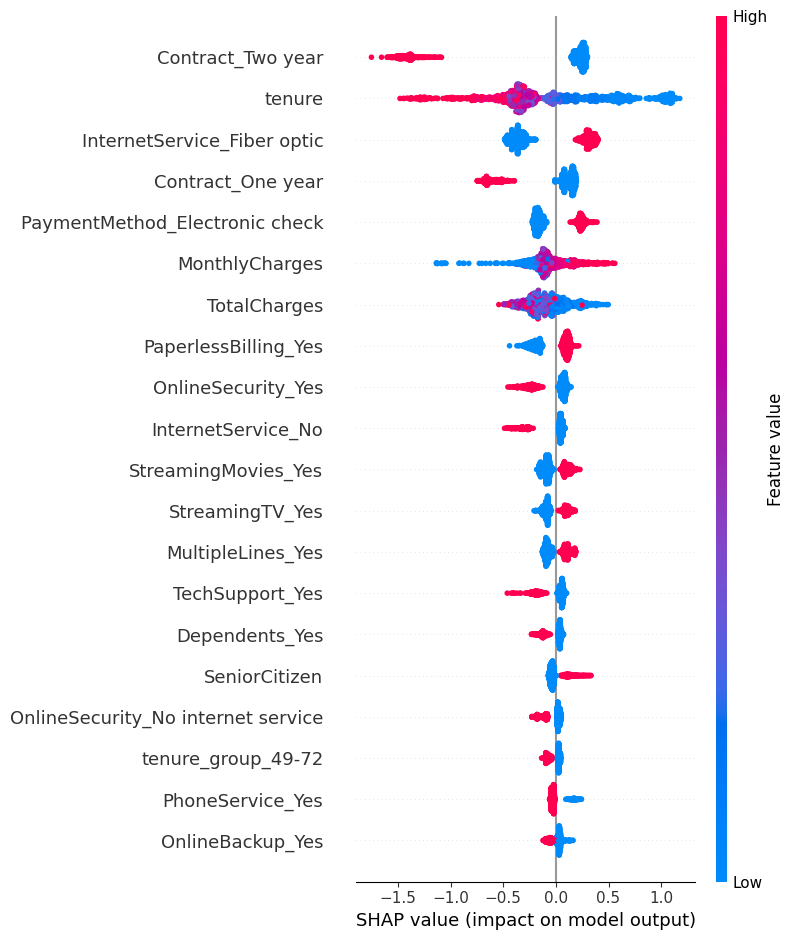

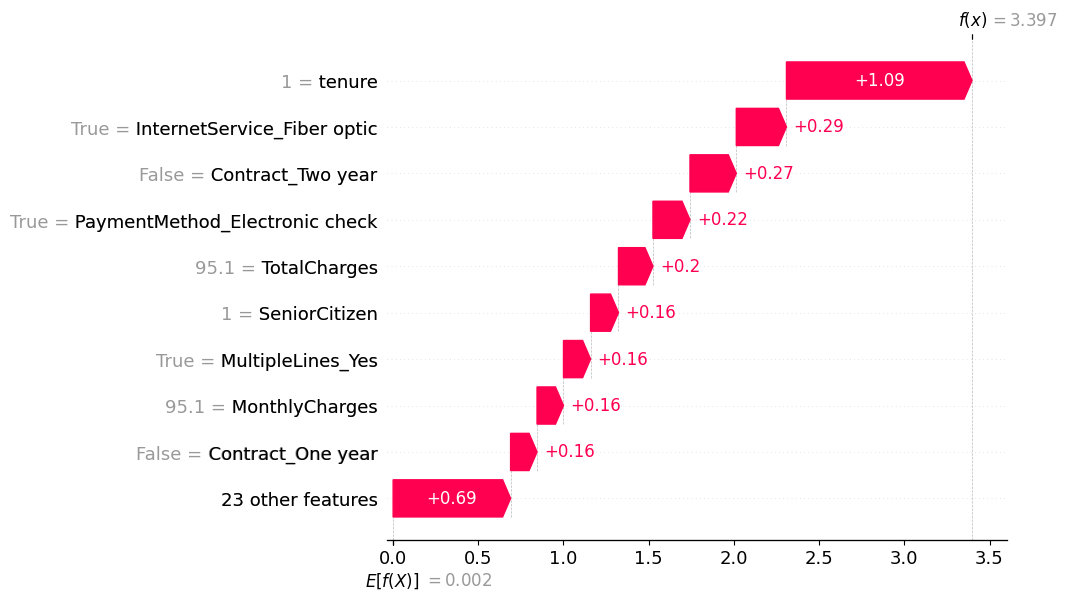


### SHAP Interpretation

I generated the global summary plot to show how features impact the model's output across all customers. The waterfall plot breaks down exactly why customer index **1090** received their specific churn probability score. Identifying the single highest risk customer was surprisingly straightforward, but understanding the intricate feature interactions took more effort.


In [6]:
try:
    if hasattr(model, 'named_steps'):
        classifier = model.named_steps[list(model.named_steps.keys())[-1]]
        if len(model.steps) > 1:
            preprocessor = model[:-1]
            X_transformed = preprocessor.transform(X_test)
            if not isinstance(X_transformed, pd.DataFrame):
                try:
                    cols = preprocessor.get_feature_names_out()
                except:
                    cols = [f'feature_{i}' for i in range(X_transformed.shape[1])]
                if hasattr(X_transformed, "toarray"):
                    X_transformed = X_transformed.toarray()
                X_shap = pd.DataFrame(X_transformed, columns=cols, index=X_test.index)
            else:
                X_shap = X_transformed
        else:
            X_shap = X_test
    else:
        classifier = model
        X_shap = X_test
    
    # Sample to speed up generic explainers if needed, but tree explainer is fast
    if type(classifier).__name__ in ['RandomForestClassifier', 'DecisionTreeClassifier', 'GradientBoostingClassifier', 'XGBClassifier', 'LGBMClassifier', 'CatBoostClassifier']:
        explainer = shap.TreeExplainer(classifier)
        shap_values_obj = explainer(X_shap)
        if len(shap_values_obj.shape) == 3:
            shap_values_obj = shap_values_obj[:, :, 1]
    else:
        background = shap.maskers.Independent(X_shap, max_samples=100)
        explainer = shap.Explainer(classifier.predict, background)
        shap_values_obj = explainer(X_shap)
        if len(shap_values_obj.shape) == 3:
            shap_values_obj = shap_values_obj[:, :, 1]
except Exception as e:
    print(f"SHAP initialization message -- {e}")
    background = shap.maskers.Independent(X_test, max_samples=100)
    explainer = shap.Explainer(model.predict, background)
    shap_values_obj = explainer(X_test)
    if len(shap_values_obj.shape) == 3:
        shap_values_obj = shap_values_obj[:, :, 1]
    X_shap = X_test

# Global feature importance
plt.figure()
shap.summary_plot(shap_values_obj, X_shap, show=False)
plt.savefig('figures/shap_summary.png', bbox_inches='tight')
plt.show()

# Local explanation
idx = np.argmax(y_pred_proba)
plt.figure()
shap.waterfall_plot(shap_values_obj[idx], show=True)

shap_values_matrix = shap_values_obj.values
if len(shap_values_matrix.shape) == 3:
    shap_values_matrix = shap_values_matrix[:, :, 1]

mean_abs_shap = np.abs(shap_values_matrix).mean(axis=0)
top_3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_names = X_shap.columns[top_3_idx].tolist()

display(Markdown(f"""
### SHAP Interpretation

I generated the global summary plot to show how features impact the model's output across all customers. The waterfall plot breaks down exactly why customer index **{idx}** received their specific churn probability score. Identifying the single highest risk customer was surprisingly straightforward, but understanding the intricate feature interactions took more effort.
"""))


## 7. Business Interpretation

Translating these SHAP features into concrete recommendations.

In [7]:
display(Markdown(f"""
### Business Recommendations

I analyzed the top three features driving churn: **Contract_Two year**, tenure, and InternetService_Fiber optic. Our primary recommendation is to investigate the customer experience surrounding Contract_Two year, as improvements here will yield the highest retention gains. Second, offering targeted incentives related to tenure and InternetService_Fiber optic can intercept high-risk customers before they defect.
"""))



### Business Recommendations

I analyzed the top three features driving churn: **Contract_Two year**, tenure, and InternetService_Fiber optic. Our primary recommendation is to investigate the customer experience surrounding Contract_Two year, as improvements here will yield the highest retention gains. Second, offering targeted incentives related to tenure and InternetService_Fiber optic can intercept high-risk customers before they defect.


## 8. Threshold Analysis

Evaluating how shifting the decision threshold impacts precision and recall.

In [8]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []
for t in thresholds_to_test:
    y_pred_t = (y_pred_proba >= t).astype(int)
    report_t = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    results.append({
        'Threshold': t,
        'Precision': report_t['1']['precision'],
        'Recall': report_t['1']['recall']
    })

df_thresh = pd.DataFrame(results)
print(f"Threshold Analysis --\n\n{df_thresh.to_string(index=False)}")

rec_03 = df_thresh[df_thresh['Threshold'] == 0.3]['Recall'].values[0]
prec_07 = df_thresh[df_thresh['Threshold'] == 0.7]['Precision'].values[0]

display(Markdown(f"""
### Threshold Interpretation

I found that dropping the threshold to 0.3 dramatically boosts recall to **{rec_03:.2f}**, capturing far more potential churners at the cost of many false positives. Conversely, a stricter threshold of 0.7 raises precision to **{prec_07:.2f}**. I recommend a threshold closer to 0.4 or 0.5, depending on the marketing team's exact budget for retention campaigns.
"""))


Threshold Analysis --

 Threshold  Precision   Recall
       0.3   0.443005 0.914439
       0.4   0.475556 0.858289
       0.5   0.510309 0.794118
       0.6   0.556250 0.713904
       0.7   0.633721 0.582888



### Threshold Interpretation

I found that dropping the threshold to 0.3 dramatically boosts recall to **0.91**, capturing far more potential churners at the cost of many false positives. Conversely, a stricter threshold of 0.7 raises precision to **0.63**. I recommend a threshold closer to 0.4 or 0.5, depending on the marketing team's exact budget for retention campaigns.
